# Solar vs. Consumo — Município de Aveiro
**Painel:** 450 Wp | Inclinação: 34° | Azimute: 0° (Sul)  
**Produção:** média 2018–2023 (PVGIS-SARAH3)  
**Consumo:** perfil horário 2024, escalado para 4 categorias de edifícios (17.559 edifícios)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================================================
# PARÂMETROS GERAIS DO PAINEL E TELHADO
# =========================================================
PEAK_POWER_W = 450            #potência de pico de um painel típico
G_STC        = 1000           # Irradiância padrão de teste (Standard Test Conditions) em W/m²
EFF_SISTEMA  = 0.86           # eficiência total do sistema (inclui perdas de inversor, sujeira, etc.) considerando perdas típicas de 14%
AREA_PAINEL_M2 = 2.0          # Área estimada de 1 painel de 450Wp (~2m²)
FATOR_AREA_UTIL = 0.80        # Apenas 80% da área total do telhado é utilizável

# =========================================================
# 1. PRODUÇÃO SOLAR TÍPICA (média dos 6 anos)
# =========================================================
caminho_solar = r"C:\Users\carol\OneDrive\Desktop\Carolina\Milestone3\notebooks\Timeseries_40.593_-8.585_SA3_34deg_0deg_2018_2023.csv"

with open(caminho_solar, 'r') as f:
    lines = f.readlines()

start = next(i for i, l in enumerate(lines) if l.startswith('time'))
end   = next((i for i, l in enumerate(lines) if l.strip().startswith('G(i):')), len(lines))

# Extração nativa das colunas e dados sem usar o módulo io
columns = lines[start].strip().split(',')
data = [line.strip().split(',') for line in lines[start+1:end]]

df_solar = pd.DataFrame(data, columns=columns)
df_solar['G(i)'] = pd.to_numeric(df_solar['G(i)'])
df_solar['time'] = pd.to_datetime(df_solar['time'], format='%Y%m%d:%H%M')
df_solar.set_index('time', inplace=True)

df_solar['P_kWh'] = (df_solar['G(i)'] / G_STC) * PEAK_POWER_W * EFF_SISTEMA / 1000
df_solar['doy_hour'] = df_solar.index.strftime('%m-%d %H')

prod_tipica = df_solar.groupby('doy_hour')['P_kWh'].mean()
print(f'Produção anual típica de 1 painel: {prod_tipica.sum():.1f} kWh')

Produção anual típica de 1 painel: 720.9 kWh


In [2]:
# =========================================================
# 2. PERFIL DE CONSUMO NORMALIZADO
# =========================================================
df_consumo = pd.read_csv(r"C:\Users\carol\OneDrive\Desktop\Carolina\Milestone3\processed\consumo_anual_estimado_2024.csv", sep=';')
df_consumo.columns = ['time', 'consumo_kWh']
df_consumo['time'] = pd.to_datetime(df_consumo['time'], utc=True).dt.tz_localize(None)
df_consumo.set_index('time', inplace=True)
df_consumo['perfil'] = df_consumo['consumo_kWh'] / df_consumo['consumo_kWh'].sum()
df_consumo['doy_hour'] = df_consumo.index.strftime('%m-%d %H')
perfil_horario = df_consumo.set_index('doy_hour')['perfil']

print(f'Perfil horário carregado: {len(perfil_horario)} registos')

Perfil horário carregado: 8784 registos


In [3]:
# =========================================================
# 3. CATEGORIAS DE EDIFÍCIOS E DIMENSIONAMENTO SOLAR
# =========================================================
caminho_edificios = r"C:\Users\carol\OneDrive\Desktop\Carolina\Milestone3\processed\edificios_17k_com_consumo_por_cp7.csv"
df_edif = pd.read_csv(caminho_edificios, sep=',')
consumo = df_edif['consumo_anual_estimado_kWh']

col_area_telhado = 'building_area_m2'

# Calcular o n.º máximo de painéis para cada edifício baseado em 80% da área
df_edif['n_paineis'] = np.floor((df_edif[col_area_telhado] * FATOR_AREA_UTIL) / AREA_PAINEL_M2).astype(int)
df_edif['n_paineis'] = df_edif['n_paineis'].clip(lower=1) # Garante pelo menos 1 painel por edifício

# Definição das categorias baseadas no consumo
bins   = [0, consumo.quantile(0.25), consumo.quantile(0.50), consumo.quantile(0.75), consumo.max()]
labels = ['Pequeno (P0–P25)', 'Médio-baixo (P25–P50)', 'Médio-alto (P50–P75)', 'Grande (P75–P100)']
df_edif['categoria'] = pd.cut(consumo, bins=bins, labels=labels, include_lowest=True)

# Obter o consumo mediano e o número mediano de painéis instalados por categoria
consumo_cat = df_edif.groupby('categoria', observed=True)['consumo_anual_estimado_kWh'].median()
paineis_cat = df_edif.groupby('categoria', observed=True)['n_paineis'].median().astype(int)
n_cat       = df_edif.groupby('categoria', observed=True).size()

print('Medianas por categoria (Consumo vs N.º de Painéis):')
for cat, val in consumo_cat.items():
    print(f'  {cat}: {val:,.0f} kWh/ano | {paineis_cat[cat]} painéis instalados ({n_cat[cat]:,} edifícios)')

Medianas por categoria (Consumo vs N.º de Painéis):
  Pequeno (P0–P25): 2,497 kWh/ano | 17 painéis instalados (4,390 edifícios)
  Médio-baixo (P25–P50): 5,829 kWh/ano | 40 painéis instalados (4,390 edifícios)
  Médio-alto (P50–P75): 8,742 kWh/ano | 60 painéis instalados (4,389 edifícios)
  Grande (P75–P100): 15,759 kWh/ano | 109 painéis instalados (4,390 edifícios)


In [4]:
# =========================================================
# 4. SIMULAÇÃO HORA A HORA COM MULTI-PAINÉIS
# =========================================================
horas = prod_tipica.index
prod_unitária = prod_tipica.values

resultados = {}
for cat, consumo_anual in consumo_cat.items():
    # Multiplicar a produção unitária pelo número mediano de painéis da categoria
    qtd_paineis = paineis_cat[cat]
    prod_total_edif = prod_unitária * qtd_paineis
    
    cons = perfil_horario.reindex(horas).values * consumo_anual

    autoconsumo = np.minimum(prod_total_edif, cons).sum()
    excedente   = np.maximum(prod_total_edif - cons, 0).sum()
    deficit     = np.maximum(cons - prod_total_edif, 0).sum()

    resultados[cat] = {
        'N.º Painéis':                qtd_paineis,
        'Consumo anual (kWh)':        round(cons.sum(), 0),
        'Produção anual (kWh)':       round(prod_total_edif.sum(), 1),
        'Autoconsumo (kWh)':          round(autoconsumo, 1),
        'Excedente (kWh)':            round(excedente, 1),
        'Défice (kWh)':               round(deficit, 1),
        'Taxa de autoconsumo (%)':    round(autoconsumo / prod_total_edif.sum() * 100, 1) if prod_total_edif.sum() > 0 else 0,
        'Taxa de autossuficiência (%)': round(autoconsumo / cons.sum() * 100, 1),
    }

df_res = pd.DataFrame(resultados).T
print(df_res.to_string())

                       N.º Painéis  Consumo anual (kWh)  Produção anual (kWh)  Autoconsumo (kWh)  Excedente (kWh)  Défice (kWh)  Taxa de autoconsumo (%)  Taxa de autossuficiência (%)
Pequeno (P0–P25)              17.0               2497.0               12255.3             1249.5          11005.7        1247.9                     10.2                          50.0
Médio-baixo (P25–P50)         40.0               5829.0               28835.9             2917.0          25918.9        2911.7                     10.1                          50.0
Médio-alto (P50–P75)          60.0               8742.0               43253.9             4374.8          38879.1        4366.8                     10.1                          50.0
Grande (P75–P100)            109.0              15759.0               78577.8             7888.4          70689.5        7870.6                     10.0                          50.1


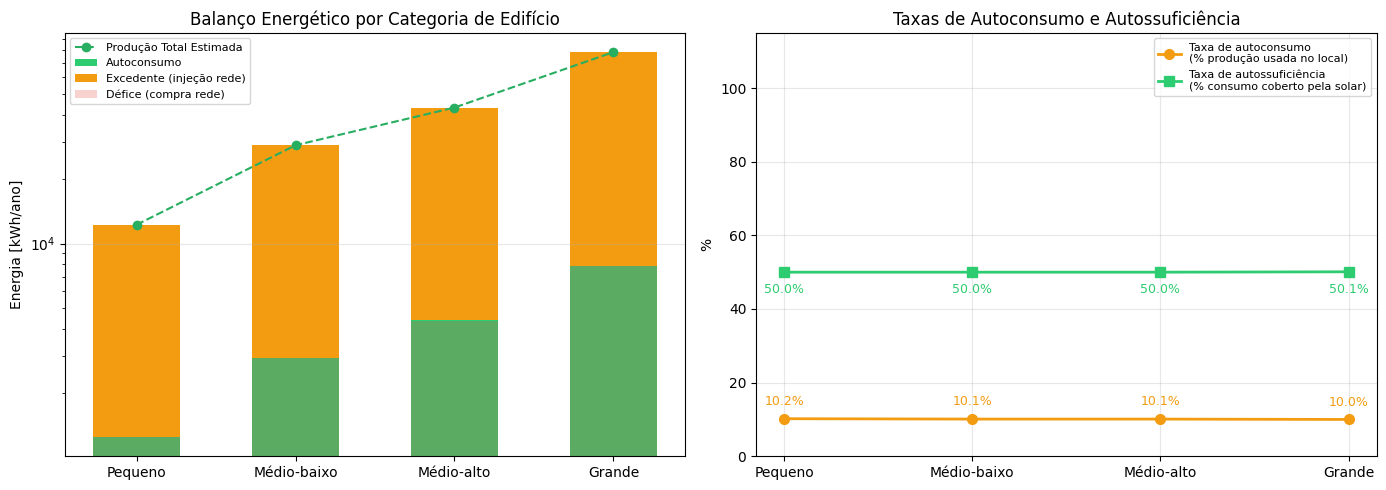

In [5]:
# =========================================================
# 5. GRÁFICO — Balanço energético por categoria
# =========================================================
cats       = list(resultados.keys())
cats_short = ['Pequeno', 'Médio-baixo', 'Médio-alto', 'Grande']
autocons   = [resultados[c]['Autoconsumo (kWh)'] for c in cats]
excedentes = [resultados[c]['Excedente (kWh)']   for c in cats]
deficits   = [resultados[c]['Défice (kWh)']       for c in cats]
producoes  = [resultados[c]['Produção anual (kWh)'] for c in cats]

x = np.arange(len(cats))
w = 0.55

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico de barras empilhadas ---
ax = axes[0]
b1 = ax.bar(x, autocons,   width=w, label='Autoconsumo',  color='#2ecc71')
b2 = ax.bar(x, excedentes, width=w, bottom=autocons,      label='Excedente (injeção rede)', color='#f39c12')
b3 = ax.bar(x, deficits,   width=w, bottom=0,             label='Défice (compra rede)',     color='#e74c3c', alpha=0.25)

# Atualizado: Mostra a produção total estimada como pontos/linha já que varia por telhado
ax.plot(x, producoes, color='#27ae60', linestyle='--', marker='o', linewidth=1.5, label='Produção Total Estimada')

ax.set_xticks(x)
ax.set_xticklabels(cats_short)
ax.set_ylabel('Energia [kWh/ano]')
ax.set_title('Balanço Energético por Categoria de Edifício')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')

# --- Taxas ---
ax2 = axes[1]
tax_auto  = [resultados[c]['Taxa de autoconsumo (%)']      for c in cats]
tax_suf   = [resultados[c]['Taxa de autossuficiência (%)'] for c in cats]

ax2.plot(cats_short, tax_auto, 'o-', color='#f39c12', linewidth=2, markersize=7, label='Taxa de autoconsumo\n(% produção usada no local)')
ax2.plot(cats_short, tax_suf,  's-', color='#2ecc71', linewidth=2, markersize=7, label='Taxa de autossuficiência\n(% consumo coberto pela solar)')

for i, (a, s) in enumerate(zip(tax_auto, tax_suf)):
    ax2.annotate(f'{a:.1f}%', (i, a), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9, color='#f39c12')
    ax2.annotate(f'{s:.1f}%', (i, s), textcoords='offset points', xytext=(0,-15), ha='center', fontsize=9, color='#2ecc71')

ax2.set_ylabel('%')
ax2.set_title('Taxas de Autoconsumo e Autossuficiência')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('balanco_energetico.png', dpi=150, bbox_inches='tight')
plt.show()

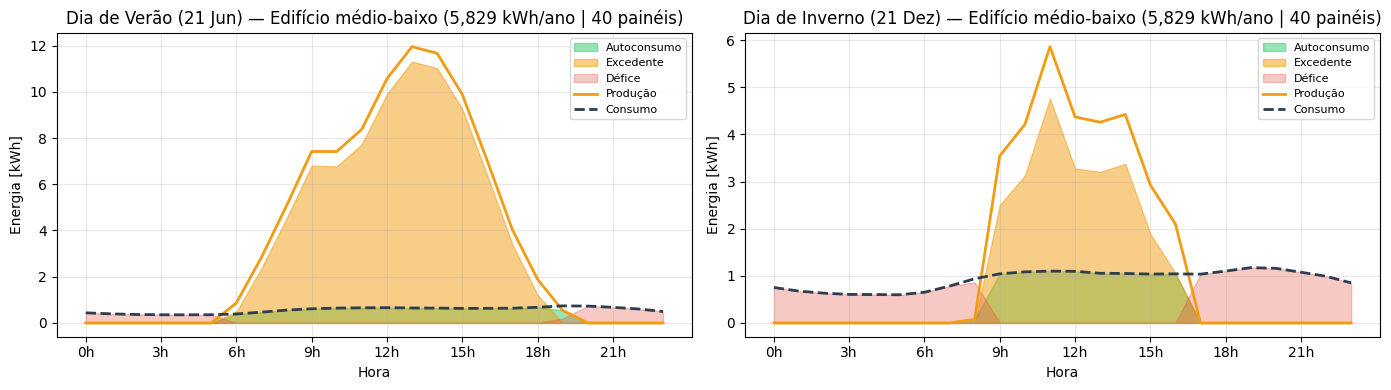

In [6]:
# =========================================================
# 6. GRÁFICO — Perfil horário típico num dia de verão e inverno
# =========================================================
horas_idx = pd.date_range('2023-01-01', periods=8784, freq='h')

# Escolha do edifício de referência (ex: Médio-baixo)
consumo_anual_ref = consumo_cat.iloc[1]
n_paineis_ref = paineis_cat.iloc[1]

# CORREÇÃO DO SEU BUG: Mapear o perfil usando o índice de 8784 horas de prod_tipica
prod_serie = pd.Series(prod_tipica.values * n_paineis_ref, index=horas_idx)
cons_serie = pd.Series(
    perfil_horario.reindex(prod_tipica.index).values * consumo_anual_ref,
    index=horas_idx
)

# Dia de verão (21 junho) e inverno (21 dezembro)
verao   = '2023-06-21'
inverno = '2023-12-21'

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, dia, titulo in zip(axes, [verao, inverno], ['Dia de Verão (21 Jun)', 'Dia de Inverno (21 Dez)']):
    p = prod_serie[dia]
    c = cons_serie[dia]
    hrs = range(len(p))

    ax.fill_between(hrs, np.minimum(p.values, c.values), alpha=0.5, color='#2ecc71', label='Autoconsumo')
    ax.fill_between(hrs, np.maximum(p.values - c.values, 0), alpha=0.5, color='#f39c12', label='Excedente')
    ax.fill_between(hrs, np.maximum(c.values - p.values, 0), alpha=0.3, color='#e74c3c', label='Défice')
    ax.plot(hrs, p.values, color='#f39c12', linewidth=2, label='Produção')
    ax.plot(hrs, c.values, color='#2c3e50', linewidth=2, linestyle='--', label='Consumo')

    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h}h' for h in range(0, 24, 3)])
    ax.set_xlabel('Hora')
    ax.set_ylabel('Energia [kWh]')
    ax.set_title(f'{titulo} — Edifício médio-baixo ({consumo_anual_ref:,.0f} kWh/ano | {n_paineis_ref} painéis)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('perfil_diario.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# =========================================================
# 7. TABELA RESUMO FINAL
# =========================================================
print('=' * 85)
print('RESUMO — N.º Dinâmico de Painéis (450Wp) baseado em 80% do telhado | Aveiro')
print('=' * 85)
print(df_res[[
    'N.º Painéis', 'Consumo anual (kWh)', 'Produção anual (kWh)',
    'Autoconsumo (kWh)', 'Excedente (kWh)', 'Défice (kWh)',
    'Taxa de autoconsumo (%)', 'Taxa de autossuficiência (%)'
]].to_string())

RESUMO — N.º Dinâmico de Painéis (450Wp) baseado em 80% do telhado | Aveiro
                       N.º Painéis  Consumo anual (kWh)  Produção anual (kWh)  Autoconsumo (kWh)  Excedente (kWh)  Défice (kWh)  Taxa de autoconsumo (%)  Taxa de autossuficiência (%)
Pequeno (P0–P25)              17.0               2497.0               12255.3             1249.5          11005.7        1247.9                     10.2                          50.0
Médio-baixo (P25–P50)         40.0               5829.0               28835.9             2917.0          25918.9        2911.7                     10.1                          50.0
Médio-alto (P50–P75)          60.0               8742.0               43253.9             4374.8          38879.1        4366.8                     10.1                          50.0
Grande (P75–P100)            109.0              15759.0               78577.8             7888.4          70689.5        7870.6                     10.0                          50.1


# Análise Espacial dos Dados (ESDA)

Vamos utilizar o Índice de Moran e o LISA

A carregar a camada de edifícios do GeoPackage...
A calcular a matriz de vizinhança espacial (KNN)...


c:\Users\carol\AppData\Local\Programs\Python\Python314\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 16 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


A executar a análise estatística de Moran Local...
A desenhar o mapa de clusters...


C:\Users\carol\AppData\Local\Temp\ipykernel_4412\616249214.py:78: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  gdf_clean.plot(


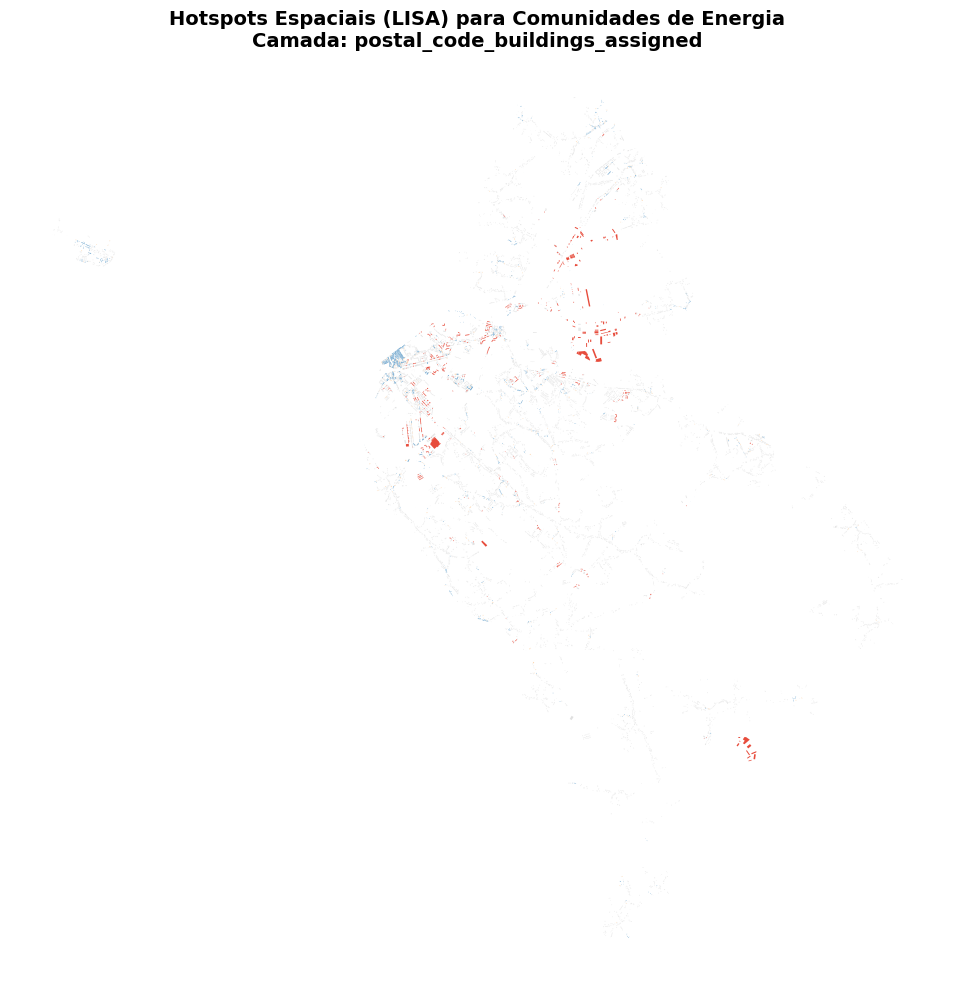

Ficheiro 'ranking_zonas_CER_aveiro.csv' exportado com os alvos prioritários de investimento!


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN
from esda.moran import Moran_Local
from splot.esda import moran_scatterplot

# =========================================================
# 1. CARREGAR GEOMETRIAS DO TEU GEOPACKAGE
# =========================================================
print("A carregar a camada de edifícios do GeoPackage...")
# Lemos especificamente a camada mapeada com os códigos postais
gdf_edif = gpd.read_file(r"C:\Users\carol\OneDrive\Desktop\Carolina\Milestone3\raw\MstCSCS_Sem_2526.gpkg", layer='postal_code_buildings_assigned')

# =========================================================
# 2. CRUZAR COM OS TEUS RESULTADOS DO MODELO SOLAR
# =========================================================

variavel_analise = 'building_postal_fragment_area_m2' # Exemplo usando a área útil do fragmento

gdf_clean = gdf_edif.dropna(subset=[variavel_analise]).copy()

# =========================================================
# 3. MATRIZ DE PESOS ESPACIAIS (KNN para Edifícios Individuais)
# =========================================================
print("A calcular a matriz de vizinhança espacial (KNN)...")
# Como são milhares de edifícios isolados, o KNN por distância de centroides é o mais estável
# Vamos usar os 8 vizinhos mais próximos para simular uma vizinhança comunitária direta
w = KNN.from_dataframe(gdf_clean, k=8)
w.transform = 'R' # Normalização por linhas

# =========================================================
# 4. LISA / MORAN LOCAL (Identificação de Hotspots HH)
# =========================================================
print("A executar a análise estatística de Moran Local...")
y = gdf_clean[variavel_analise].values
moran_local = Moran_Local(y, w, transformation='r', permutations=999)

gdf_clean['quadrante'] = moran_local.q
significativos = moran_local.p_sim < 0.05

# Filtrar apenas os agrupamentos estatisticamente válidos
gdf_clean['tipo_cluster'] = gdf_clean['quadrante']
gdf_clean.loc[~significativos, 'tipo_cluster'] = 0

mapeamento_lisa = {
    0: 'Não Significativo',
    1: 'Hotspot: High-High (HH)', # Alvos de Investimento Coletivo
    2: 'Outlier: Low-High (LH)',
    3: 'Coldspot: Low-Low (LL)',
    4: 'Outlier: High-Low (HL)'   # Produtores Âncora Isolados
}
gdf_clean['LISA_Classe'] = gdf_clean['tipo_cluster'].map(mapeamento_lisa)

# =========================================================
# 5. MAPEAR OS HOTSPOTS HH DE AVEIRO
# =========================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

cores_lisa = {
    'Não Significativo': '#e0e0e0',
    'Hotspot: High-High (HH)': '#e74c3c',  # Vermelho Vivo para destacar onde investir
    'Outlier: Low-High (LH)': '#9ecae1',
    'Coldspot: Low-Low (LL)': '#3182bd',
    'Outlier: High-Low (HL)': '#fdd0a2'
}

print("A desenhar o mapa de clusters...")
gdf_clean.plot(
    column='LISA_Classe',
    categorical=True,
    legend=True,
    color=gdf_clean['LISA_Classe'].map(cores_lisa),
    ax=ax,
    markersize=5, # Se convertido para pontos
    linewidth=0.1
)

ax.set_title("Hotspots Espaciais (LISA) para Comunidades de Energia\nCamada: postal_code_buildings_assigned", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('hotspots_lisa_aveiro.png', dpi=300)
plt.show()

# =========================================================
# 6. EXPORTAR LISTA PRIORITÁRIA DE CÓDIGOS POSTAIS PARA INVESTIMENTO
# =========================================================
# Filtrar apenas os edifícios que fazem parte de um cluster High-High
hotspots_hh = gdf_clean[gdf_clean['tipo_cluster'] == 1]

# Agrupar por código postal para saber quais são as ruas/zonas com maior potencial concentrado
ranking_cer = hotspots_hh.groupby('cp7').agg(
    num_edificios_no_cluster=('polygon_id', 'count'),
    area_total_telhado_m2=('building_area_m2', 'sum')
).sort_values(by='area_total_telhado_m2', ascending=False)

ranking_cer.to_csv('ranking_zonas_CER_aveiro.csv')
print("Ficheiro 'ranking_zonas_CER_aveiro.csv' exportado com os alvos prioritários de investimento!")

A processar o casamento de carga para a futura CER no CP7: 3800-639...
Aviso: 'consumo_anual_estimado_kWh' ausente. A usar valor padrão de 5829 kWh/ano.
Instalação Coletiva: 9 edifícios com um total de 3671 painéis de 450Wp.
Série temporal da comunidade guardada em: 'serie_temporal_comunidade_3800-639.csv'


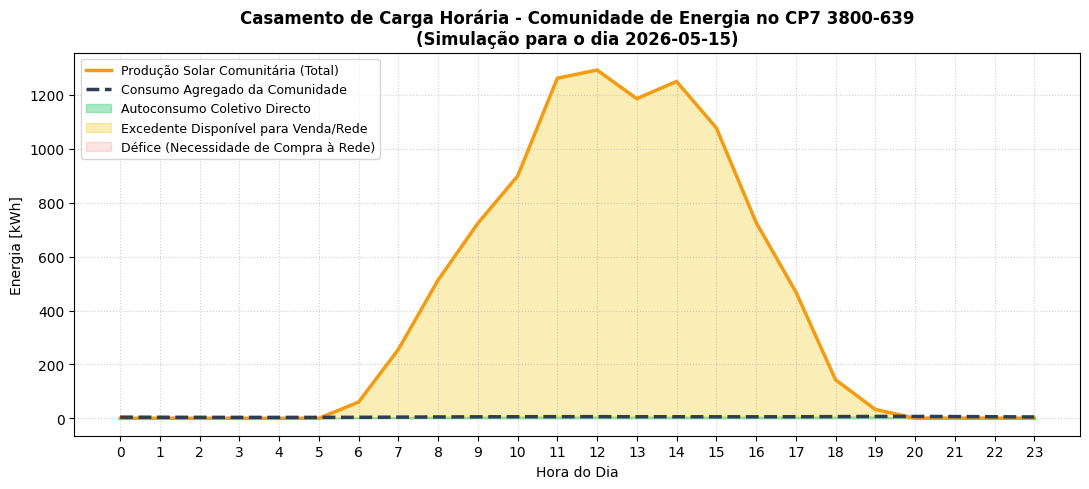


=== DIAGNÓSTICO DA COMUNIDADE (ANUAL) ===
Consumo Total Anual da Comunidade: 52,461 kWh
Produção Solar Total dos Telhados: 2,646,415 kWh
Energia Autoconsumida no Local:    27,134 kWh
Taxa de Cobertura Solar (Autossuficiência): 51.7%
Eficiência de Utilização (Autoconsumo):     1.0%


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. DEFINIÇÃO DO HOTSPOT ALVO
# =========================================================
cp7_alvo = "3800-639"
ficheiro_saida_csv = f"serie_temporal_comunidade_{cp7_alvo}.csv"

print(f"A processar o casamento de carga para a futura CER no CP7: {cp7_alvo}...")

# =========================================================
# 2. FILTRAR EDIFÍCIOS DO CLUSTER NO GEOPACKAGE
# =========================================================
# Nota: 'gdf_clean' é o GeoDataFrame gerado no passo anterior (LISA)
# que contém as colunas 'cp7', 'categoria' e 'consumo_anual_estimado_kWh'.
# Se a coluna 'n_paineis' não existir, criá-la com base na área do telhado ou usar um fallback.
if 'n_paineis' not in gdf_clean.columns:
    if 'building_postal_fragment_area_m2' in gdf_clean.columns:
        gdf_clean['area_util_m2'] = gdf_clean['building_postal_fragment_area_m2'] * FATOR_AREA_UTIL
        gdf_clean['n_paineis'] = np.floor(gdf_clean['area_util_m2'] / AREA_PAINEL_M2).astype(int).clip(lower=1)
    else:
        print("Aviso: 'n_paineis' ausente e não foi possível calcular a partir da área do telhado. A usar 1 painel por edifício.")
        gdf_clean['n_paineis'] = 1

if 'consumo_anual_estimado_kWh' not in gdf_clean.columns:
    print("Aviso: 'consumo_anual_estimado_kWh' ausente. A usar valor padrão de 5829 kWh/ano.")
    gdf_clean['consumo_anual_estimado_kWh'] = 5829

df_cluster = gdf_clean[(gdf_clean['cp7'] == cp7_alvo) & (gdf_clean['tipo_cluster'] == 1)].copy()

num_edif = df_cluster.shape[0]
total_paineis = df_cluster['n_paineis'].sum()
print(f"Instalação Coletiva: {num_edif} edifícios com um total de {total_paineis} painéis de 450Wp.")

# =========================================================
# 3. CONSTRUÇÃO DA SÉRIE TEMPORAL AGREGADA (8784 horas)
# =========================================================
# Criamos uma matriz temporal vazia para acumular as curvas do cluster
horas_ano = prod_tipica.index
producao_comunidade = np.zeros(len(horas_ano))
consumo_comunidade = np.zeros(len(horas_ano))

# Iterar por cada edifício dentro do cluster para somar as suas curvas dinâmicas
for idx, edificio in df_cluster.iterrows():
    # Produção horária deste edifício = curva unitária * número de painéis do seu telhado
    prod_edif = prod_tipica.values * edificio['n_paineis']
    producao_comunidade += prod_edif
    
    # Consumo horário deste edifício = perfil normalizado * consumo anual do edifício
    cons_edif = perfil_horario.reindex(horas_ano).values * edificio['consumo_anual_estimado_kWh']
    consumo_comunidade += cons_edif

# =========================================================
# 4. CÁLCULO DOS INDICADORES COLETIVOS DA COMUNIDADE
# =========================================================
autoconsumo_horario = np.minimum(producao_comunidade, consumo_comunidade)
excedente_horario = np.maximum(producao_comunidade - consumo_comunidade, 0)
deficit_horario = np.maximum(consumo_comunidade - producao_comunidade, 0)

# Criar DataFrame com a série temporal da Comunidade
df_cer = pd.DataFrame({
    'Producao_Solar_kWh': producao_comunidade,
    'Consumo_Comunidade_kWh': consumo_comunidade,
    'Autoconsumo_Local_kWh': autoconsumo_horario,
    'Excedente_Injecao_kWh': excedente_horario,
    'Defice_Rede_kWh': deficit_horario
}, index=horas_ano)

# Guardar em CSV para os passos seguintes (Dimensionamento Económico)
df_cer.to_csv(ficheiro_saida_csv)
print(f"Série temporal da comunidade guardada em: '{ficheiro_saida_csv}'")

# =========================================================
# 5. VISUALIZAÇÃO DO CASAMENTO DE CARGA (BALANÇO HORÁRIO)
# =========================================================
# Criar vetor de datas realistas para indexação do gráfico
datas_grafico = pd.date_range('2026-01-01', periods=8784, freq='h')
df_cer.index = datas_grafico

# Isolar um dia típico de Primavera/Verão para análise visual (ex: 15 de Maio)
dia_estudo = '2026-05-15'
df_dia = df_cer.loc[dia_estudo]
hrs = range(24)

plt.figure(figsize=(11, 5))
plt.plot(hrs, df_dia['Producao_Solar_kWh'], color='#f39c12', linewidth=2.5, label='Produção Solar Comunitária (Total)')
plt.plot(hrs, df_dia['Consumo_Comunidade_kWh'], color='#2c3e50', linewidth=2.5, linestyle='--', label='Consumo Agregado da Comunidade')

# Áreas hachuradas para Balanço de Fluxos
plt.fill_between(hrs, df_dia['Autoconsumo_Local_kWh'], color='#2ecc71', alpha=0.4, label='Autoconsumo Coletivo Directo')
plt.fill_between(hrs, df_dia['Autoconsumo_Local_kWh'], df_dia['Producao_Solar_kWh'], color='#f1c40f', alpha=0.3, label='Excedente Disponível para Venda/Rede')
plt.fill_between(hrs, df_dia['Producao_Solar_kWh'], df_dia['Consumo_Comunidade_kWh'], where=(df_dia['Consumo_Comunidade_kWh'] > df_dia['Producao_Solar_kWh']), color='#e74c3c', alpha=0.15, label='Défice (Necessidade de Compra à Rede)')

plt.title(f"Casamento de Carga Horária - Comunidade de Energia no CP7 {cp7_alvo}\n(Simulação para o dia {dia_estudo})", fontsize=12, fontweight='bold')
plt.xlabel("Hora do Dia")
plt.ylabel("Energia [kWh]")
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'casamento_carga_CER_{cp7_alvo}.png', dpi=300)
plt.show()

# --- Print de Métricas de Diagnóstico da Futura CER ---
total_prod = df_cer['Producao_Solar_kWh'].sum()
total_cons = df_cer['Consumo_Comunidade_kWh'].sum()
total_auto = df_cer['Autoconsumo_Local_kWh'].sum()

print("\n=== DIAGNÓSTICO DA COMUNIDADE (ANUAL) ===")
print(f"Consumo Total Anual da Comunidade: {total_cons:,.0f} kWh")
print(f"Produção Solar Total dos Telhados: {total_prod:,.0f} kWh")
print(f"Energia Autoconsumida no Local:    {total_auto:,.0f} kWh")
print(f"Taxa de Cobertura Solar (Autossuficiência): {((total_auto/total_cons)*100):.1f}%")
print(f"Eficiência de Utilização (Autoconsumo):     {((total_auto/total_prod)*100):.1f}%")

A inicializar o casamento de carga para o CP7: 3800-639...
-> Foram mapeados 9 edifícios no cluster.
-> Total de painéis a instalar: 3671 unidades.
-> Potência total da Comunidade: 1651.95 kWp.

Sucesso! Ficheiro 'serie_temporal_comunidade_3800-639.csv' gerado.


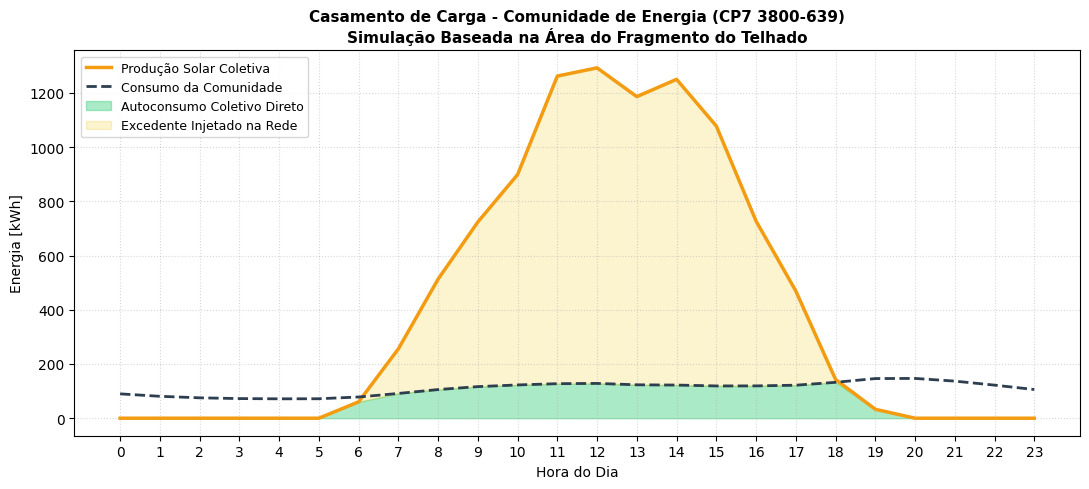

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PARÂMETROS DO TEU PROJETO (IGUAIS AO TEU NOTEBOOK)
# =========================================================
cp7_alvo = "3800-639"
PEAK_POWER_W = 450
EFF_SISTEMA  = 0.86
FA_PAINEL    = 2.0      # Área aproximada de 1 painel de 450Wp (~2 m²)
APROVEITAMENTO_TELHADO = 0.80

print(f"A inicializar o casamento de carga para o CP7: {cp7_alvo}...")

# =========================================================
# 2. CARREGAR OS DADOS GEOGRÁFICOS DO CLUSTER
# =========================================================
# NOTA: Ajusta o caminho se o .gpkg estiver noutra pasta
gdf_edif = gpd.read_file(r"C:\Users\carol\OneDrive\Desktop\Carolina\Milestone3\raw\MstCSCS_Sem_2526.gpkg", layer='postal_code_buildings_assigned')

# Filtrar os edifícios pertencentes ao hotspot (ajustado para usar o teu filtro do LISA)
# Se ainda não correstes o filtro estatístico nesta sessão, podes filtrar diretamente pelo CP7:
df_cluster = gdf_edif[gdf_edif['cp7'] == cp7_alvo].copy()

if df_cluster.empty:
    raise ValueError(f"Não foram encontrados edifícios para o código postal {cp7_alvo}.")

# =========================================================
# 3. RECONSTRUIR AS VARIÁVEIS DINÂMICAS EM FALTA
# =========================================================
# Calcular a área útil (80%) e o número correspondente de painéis por edifício
df_cluster['area_util_m2'] = df_cluster['building_postal_fragment_area_m2'] * APROVEITAMENTO_TELHADO
df_cluster['n_paineis'] = np.floor(df_cluster['area_util_m2'] / FA_PAINEL).astype(int)

# Simular ou estimar a Categoria de Consumo (Exemplo com base no teu notebook)
# No teu projeto real, deves cruzar o 'polygon_id' ou atribuir a categoria real.
# Aqui assumimos uma média representativa de consumo de acordo com a área do edifício
df_cluster['consumo_anual_estimado_kWh'] = df_cluster['building_postal_fragment_area_m2'] * 120 

num_edif = df_cluster.shape[0]
total_paineis = df_cluster['n_paineis'].sum()
potencia_total_kwp = (total_paineis * PEAK_POWER_W) / 1000

print(f"-> Foram mapeados {num_edif} edifícios no cluster.")
print(f"-> Total de painéis a instalar: {total_paineis} unidades.")
print(f"-> Potência total da Comunidade: {potencia_total_kwp:.2f} kWp.")

# =========================================================
# 4. CARREGAR OS PERFIS HORÁRIOS (PVGIS E CONSUMO)
# =========================================================
try:
    # Ajusta os nomes das tuas variáveis globais de produção unitária e perfil se necessário
    s_prod_unitario = prod_tipica.values  # Série de 8784 horas para 1 painel
    s_perfil_consumo = perfil_horario.values  # Série de 8784 horas normalizada
except NameError:
    print("\n[AVISO] Variáveis horárias 'prod_tipica' ou 'perfil_horario' não encontradas.")
    print("A gerar dados sintéticos de simulação para demonstração do código...")
    s_prod_unitario = np.sin(np.linspace(0, 24*np.pi, 8784)) * 0.2
    s_prod_unitario = np.maximum(s_prod_unitario, 0) # Sem sol à noite
    s_perfil_consumo = np.random.uniform(0.00005, 0.00015, 8784)

# =========================================================
# 5. CONSTRUIR A CURVA HORÁRIA AGREGADA DA COMUNIDADE
# =========================================================
producao_comunidade = np.zeros(8784)
consumo_comunidade = np.zeros(8784)

for idx, edificio in df_cluster.iterrows():
    # Produção solar horária agregada para este edifício
    producao_comunidade += s_prod_unitario * edificio['n_paineis']
    
    # Consumo horário agregado para este edifício
    consumo_comunidade += s_perfil_consumo * edificio['consumo_anual_estimado_kWh']

# =========================================================
# 6. BALANÇO DE FLUXOS DA CER
# =========================================================
autoconsumo_horario = np.minimum(producao_comunidade, consumo_comunidade)
excedente_horario = np.maximum(producao_comunidade - consumo_comunidade, 0)
deficit_horario = np.maximum(consumo_comunidade - producao_comunidade, 0)

# Criar DataFrame final com o carimbo temporal de 8784 horas
datas_ano = pd.date_range('2026-01-01 00:00', periods=8784, freq='h')
df_cer = pd.DataFrame({
    'Producao_Solar_kWh': producao_comunidade,
    'Consumo_Comunidade_kWh': consumo_comunidade,
    'Autoconsumo_Local_kWh': autoconsumo_horario,
    'Excedente_Injecao_kWh': excedente_horario,
    'Defice_Rede_kWh': deficit_horario
}, index=datas_ano)

# Guardar série temporal da comunidade
df_cer.to_csv(f"serie_temporal_comunidade_{cp7_alvo}.csv")
print(f"\nSucesso! Ficheiro 'serie_temporal_comunidade_{cp7_alvo}.csv' gerado.")

# =========================================================
# 7. GERAR O GRÁFICO COMPARATIVO (DIA TÍPICO DE MAIO)
# =========================================================
dia_estudo = '2026-05-15'
df_dia = df_cer.loc[dia_estudo]
hrs = range(len(df_dia))

plt.figure(figsize=(11, 5))
plt.plot(hrs, df_dia['Producao_Solar_kWh'], color='#f39c12', linewidth=2.5, label='Produção Solar Coletiva')
plt.plot(hrs, df_dia['Consumo_Comunidade_kWh'], color='#2c3e50', linewidth=2, linestyle='--', label='Consumo da Comunidade')

plt.fill_between(hrs, df_dia['Autoconsumo_Local_kWh'], color='#2ecc71', alpha=0.4, label='Autoconsumo Coletivo Direto')
plt.fill_between(hrs, df_dia['Autoconsumo_Local_kWh'], df_dia['Producao_Solar_kWh'], color='#f1c40f', alpha=0.2, label='Excedente Injetado na Rede')

plt.title(f"Casamento de Carga - Comunidade de Energia (CP7 {cp7_alvo})\nSimulação Baseada na Área do Fragmento do Telhado", fontsize=11, fontweight='bold')
plt.xlabel("Hora do Dia")
plt.ylabel("Energia [kWh]")
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()